# Project 2 — Fraud Detection

This notebook trains a fraud-classification model using SMOTE and compares logistic regression with random forest.

Imports completed successfully.

Loading data...
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.7982

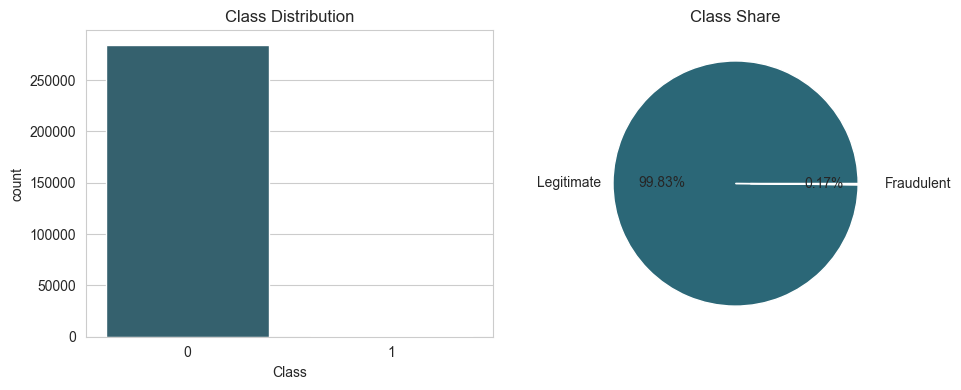


Train shape: (227845, 30)
Test shape: (56962, 30)
Fraud rate in train: 0.00173
Fraud rate in test: 0.00172
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best LR params: {'classifier__C': 0.01, 'smote__k_neighbors': 5}
Best LR CV ROC-AUC: 0.9807
Fitting 5 folds for each of 9 candidates, totalling 45 fits


KeyboardInterrupt: 

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style("whitegrid")
RANDOM_STATE = 42

print("Imports completed successfully.")

# Load data
print("\nLoading data...")
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print(df.head())
print("\nData info:")
df.info()
print("\nMissing values:", df.isnull().sum().sum())

# Class balance
print("\nClass distribution:")
class_counts = df["Class"].value_counts()
class_percent = df["Class"].value_counts(normalize=True) * 100
print("Total transactions:", len(df))
print(f"Legitimate (0): {class_counts[0]} ({class_percent[0]:.2f}%)")
print(f"Fraudulent (1): {class_counts[1]} ({class_percent[1]:.2f}%)")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x="Class", data=df, hue="Class", palette=["#2b6777", "#e8622c"], legend=False)
plt.title("Class Distribution")

plt.subplot(1, 2, 2)
plt.pie(
    class_counts,
    labels=["Legitimate", "Fraudulent"],
    autopct="%1.2f%%",
    colors=["#2b6777", "#e8622c"],
    explode=(0, 0.12),
)
plt.title("Class Share")
plt.tight_layout()
plt.show()

# Train/test split
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Fraud rate in train:", round(y_train.mean(), 5))
print("Fraud rate in test:", round(y_test.mean(), 5))

# Build pipelines
pipe_lr = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

pipe_rf = ImbPipeline(
    steps=[
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)

# Tune models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid_lr = {
    "smote__k_neighbors": [3, 5, 7],
    "classifier__C": [0.01, 0.1, 1.0],
}

param_grid_rf = {
    "smote__k_neighbors": [3, 5, 7],
    "classifier__max_depth": [10, 20, None],
}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_lr.fit(X_train, y_train)
print("\nBest LR params:", grid_lr.best_params_)
print("Best LR CV ROC-AUC:", round(grid_lr.best_score_, 4))

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_rf.fit(X_train, y_train)
print("\nBest RF params:", grid_rf.best_params_)
print("Best RF CV ROC-AUC:", round(grid_rf.best_score_, 4))

# Evaluation helper
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n===== {name} =====")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraudulent"]))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraudulent"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.show()

    return {
        "name": name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "y_proba": y_proba,
    }

best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_
results_lr = evaluate_model("Logistic Regression", best_lr, X_test, y_test)
results_rf = evaluate_model("Random Forest", best_rf, X_test, y_test)

# ROC curve comparison
plt.figure(figsize=(6, 6))
for res in [results_lr, results_rf]:
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    roc_area = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{res['name']} (AUC = {roc_area:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression vs Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Side-by-side comparison
comparison_df = pd.DataFrame(
    [
        {"Model": results_lr["name"], "Precision": results_lr["precision"], "Recall": results_lr["recall"], "F1-score": results_lr["f1"], "ROC-AUC": results_lr["roc_auc"]},
        {"Model": results_rf["name"], "Precision": results_rf["precision"], "Recall": results_rf["recall"], "F1-score": results_rf["f1"], "ROC-AUC": results_rf["roc_auc"]},
    ]
).set_index("Model")
print("\nModel comparison:")
print(comparison_df.round(4))

comparison_df.plot(kind="bar", figsize=(8, 5), colormap="viridis")
plt.title("Precision / Recall / F1 / ROC-AUC — Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature importance
rf_classifier = best_rf.named_steps["classifier"]
importances = pd.Series(rf_classifier.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", color="#2b6777")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 10. Random Forest Feature Importance

As a bonus diagnostic, the Random Forest's feature importances show which features contribute most to separating fraud from legitimate transactions.

In [ ]:
rf_classifier = best_rf.named_steps["classifier"]
importances = pd.Series(rf_classifier.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh", color="#2b6777")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 11. Conclusion

- The dataset is extremely imbalanced (~0.17% fraud), so **Accuracy was discarded** as an evaluation metric in favor of **Precision, Recall, and ROC-AUC**.
- **SMOTE** was applied strictly inside the training fold via `imblearn.pipeline.Pipeline`, never before the train/test split — eliminating data leakage.
- Two classifiers were tuned holistically with `GridSearchCV` (5-fold `StratifiedKFold`, tuning both `smote__k_neighbors` and the classifier's own hyperparameters together): **Logistic Regression** (with `StandardScaler`, since it's scale-sensitive) and **Random Forest** (scale-invariant, no scaler needed).
- Final evaluation was run once, on the untouched, still-imbalanced test set, to reflect real-world conditions.

The comparison table and ROC curve above show which of the two models generalizes better at separating fraudulent transactions from legitimate ones.